# eBPF Bottleneck Classifier v6 — 3-Class Merge (Normal / Medium / High), Imbalance Handling & Feature Validation

**Built on the v4 results:** Accuracy ≈ 69%, Weighted F1 ≈ 0.70, Macro F1 ≈ 0.63 (Random Forest / LightGBM, leakage-free feature set, dynamic percentile labels).

This notebook does **not** repeat full EDA. It picks up exactly where the v4 review left off and runs the four
highest-priority follow-ups in order:

| Section | Addresses |
|---|---|
| 1 | Rebuild the leakage-free feature set (carried over from v4, condensed) |
| 2 | Stratified train/test split |
| 3 | **Class imbalance**: baseline vs `class_weight='balanced'` vs SMOTE vs Borderline-SMOTE vs ADASYN |
| 4 | **Feature scaling** with `StandardScaler` (fit on train only) + a neural model (MLP) comparison |
| 5 | **Feature importance**: RF impurity importance vs permutation importance vs SHAP |
| 6 | **Confusion matrix + misclassified-sample inspection** for the champion model |
| 7 | **Medium-class overlap investigation**: class-wise distributions of the diagnostic (non-feature) stall columns |
| 8 | Final comparison table, champion selection, and artifact saving |

**Rules enforced throughout (per the v4 review's "Avoid" list):**
- Resampling (SMOTE/ADASYN/etc.) is fit **only** on `X_train`/`y_train`, never on the test set.
- `StandardScaler` is fit **only** on `X_train`, then applied to `X_test` — no whole-dataset normalization.
- No features are dropped on the basis of Pearson correlation alone; importance is triangulated across three
  independent methods (impurity, permutation, SHAP) before any feature is treated as unimportant.
- Evaluation always reports **Macro F1** and **per-class recall/precision**, not just accuracy.

---
# Section 1 — Load & Rebuild the Leakage-Free Feature Set
Condensed from v4 Sections 1–4. If you already have `df` with `FEATURE_COLS` in memory from v4, you can skip to Section 2.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, f1_score, accuracy_score
)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [2]:
# ── Load multiple CSV parts (manually named, no auto-discovery) ──────────────
CSV_PARTS = [
    'perf_metrics1.csv',
    'perf_metrics2.csv',
    # 'perf_metrics2.csv',
    # add more here as you collect them
]
# ──────────────────────────────────────────────────────────────────────────────

dfs = []
for path in CSV_PARTS:
    if not os.path.exists(path):
        print(f"  skipping (not found): {path}")
        continue
    part = pd.read_csv(path)
    part['source_file'] = path
    dfs.append(part)
    print(f"  loaded {path:<20}: {len(part):>8} rows")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_raw.shape}")
print(f"Sessions found : {df_raw['session_label'].unique().tolist()}")
df_raw['session_label'].value_counts()

  loaded perf_metrics1.csv   :   526895 rows
  loaded perf_metrics2.csv   :   250683 rows

Combined shape: (777578, 45)
Sessions found : ['idle', 'cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_low', 'mem_high', 'io_low', 'lock_low', 'mixed_load', 'cpu_extreme', 'cpu_ultra', 'mem_extreme', 'mem_thrashing', 'cpu_mem_extreme', 'cpu_mem_ultra', 'io_extreme', 'cpu_io_extreme', 'lock_extreme', 'lock_cpu_mix', 'everything_max', 'everything_insane', 'cpu_2x', 'cpu_4x', 'cpu_8x', 'mem_reclaim', 'mem_heavy_reclaim', 'cpu_mem_2x', 'cpu_mem_4x', 'cpu_mem_8x', 'cpu_mem_io', 'cpu_mem_io_heavy', 'lock_heavy', 'lock_cpu_heavy', 'everything_extreme', 'compile_only', 'compile_sysbench', 'compile_blender', 'full_system', 'mem_swap_thrashing', 'cpu_l3_cache_misses', 'mem_swap_thrash', 'mem_tlb_cache_miss', 'io_async_saturation', 'ctx_flood', 'llm_inference', 'ml_training', 'stream_memory_contention', 'cache_contention', 'context_switch_contention']


session_label
stream_memory_contention     146855
cache_contention             133428
context_switch_contention    121529
llm_inference                 39621
everything_max                21993
ml_training                   21422
everything_insane             20568
lock_cpu_heavy                11752
cpu_8x                        10213
lock_low                      10112
lock_heavy                     9933
everything_extreme             9705
cpu_mem_io                     9449
cpu_medium                     9261
full_system                    8964
cpu_low                        8331
cpu_mem_io_heavy               8082
cpu_mem_4x                     8024
cpu_mem_8x                     7969
mem_low                        7914
mem_extreme                    7764
mem_reclaim                    7449
compile_only                   6823
cpu_mem_2x                     6718
io_low                         6653
compile_sysbench               6585
compile_blender                6570
mem_tlb_cache_

In [3]:
# ── CLEANING (same rules as v4) ───────────────────────────────────────────────
df = df_raw.copy()
before = len(df)

df = df[df['pid'] > 0]
df = df[df['ctx_switches'] > 0]
df = df[df['latency_count'] > 0]

print(f"Cleaned: {before} → {len(df)} rows ({before - len(df)} removed)")

Cleaned: 777578 → 664256 rows (113322 removed)


---
### Threshold calibration (run this once before picking `NORMAL_THRESHOLD_NS` / `HIGH_THRESHOLD_NS` below)

reader.c's `2ms / 10ms / 50ms` are guessed defaults, not calibrated to this system's actual `avg_stall_ns`
distribution. The cell below prints the real percentile ladder (in ms) and a grid of candidate threshold
pairs with the resulting class balance for each, so you can pick fixed cutoffs that are informed by the data
but still hardcoded/reproducible — not recomputed per-run like v5's percentile approach.

Read the percentile table first: find where the distribution actually starts spreading out (the jump between
consecutive percentiles gets big) — that inflection is a better candidate boundary than an arbitrary round
number. Then sanity-check candidates against the grid so you're not left with a near-empty class.


In [ ]:
# ── LABEL DERIVATION (fixed thresholds, matching reader.c's original design) ──
# reader.c hardcodes these thresholds itself and prints them as its own suggested
# Jupyter snippet at the end of every collection run:
#   avg_stall_ns <  2ms            -> class 0 (Normal)
#   2ms <= avg_stall_ns < 10ms     -> class 1 (Low)
#   10ms <= avg_stall_ns < 50ms    -> class 2 (Medium)
#   avg_stall_ns >= 50ms           -> class 3 (High)
# v5 instead computed p50/p85/p97 quantiles of avg_stall_ns from the collected data
# and binned on those. That makes "High" mean something different every time the
# session mix changes, which isn't reproducible or physically grounded. Reverting to
# reader.c's fixed absolute cutoffs fixes that.
#
# v6 also merges Low+Medium into a single "Medium" class — they overlapped heavily in
# v5 (see the Section 7 violin plots) and contributed most of the misclassifications.
# The actual goal is bottleneck *detection*, so the model should spend its capacity
# cleanly separating High (the class that matters) from everything else, instead of
# trying to draw a fine line between two similar "not that bad" buckets.
NORMAL_THRESHOLD_NS = 500_000      # 0.5 ms
HIGH_THRESHOLD_NS   = 1_500_000    # 1.5 ms
bins = [0, NORMAL_THRESHOLD_NS, HIGH_THRESHOLD_NS, float('inf')]

labels = [0, 1, 2]
class_names_map = {0: 'Normal', 1: 'Medium', 2: 'High'}
TARGET_NAMES  = ['Normal', 'Medium', 'High']
TARGET_LABELS = [0, 1, 2]

df['y'] = pd.cut(df['avg_stall_ns'], bins=bins, labels=labels).astype(int)
df['y_name'] = df['y'].map(class_names_map)

print(f"Fixed thresholds (ns, from reader.c): "
      f"Normal < {NORMAL_THRESHOLD_NS:,}  |  High >= {HIGH_THRESHOLD_NS:,}\n")
for cls in TARGET_LABELS:
    count = (df['y'] == cls).sum()
    pct = 100 * count / len(df)
    print(f"  Class {cls} ({class_names_map[cls]:<6}): {count:5d} rows  ({pct:5.1f}%)")


Fixed thresholds (ns, from reader.c): Normal < 100,000  |  High >= 1,000,000

  Class 0 (Normal): 285447 rows  ( 43.0%)
  Class 1 (Medium): 341599 rows  ( 51.4%)
  Class 2 (High  ): 37210 rows  (  5.6%)


In [10]:
# ── FEATURE ENGINEERING (causal signals only — same as v4) ───────────────────
df['involuntary_ratio']  = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']    = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)
df['runtime_per_switch'] = df['total_runtime_ns']     / df['ctx_switches'].clip(lower=1)
df['read_write_ratio']   = df['read_bytes'] / (df['write_bytes'] + 1)
df['io_bytes_total']     = df['read_bytes'] + df['write_bytes']
df['alloc_pressure']     = df['total_alloc_bytes'] / df['ctx_switches'].clip(lower=1)
df['lock_pressure']      = (
    df['mutex_contentions'] + df['rwsem_read_contentions'] + df['rwsem_write_contentions']
)

log_cols = ['total_runtime_ns', 'avg_syscall_latency_ns', 'max_syscall_latency_ns',
            'io_bytes_total', 'total_alloc_bytes']
for col in log_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

print(f"Features after engineering: {df.shape[1]} columns")

Features after engineering: 59 columns


In [11]:
# ── EXPLICIT ALLOWLIST (no data leakage) — identical to v4 ───────────────────
LEAKY_COLS = {
    'avg_stall_ns', 'stall_ns', 'max_stall_ns', 'latency_count',
    'stall_per_switch', 'log_stall_ns', 'log_avg_stall_ns', 'log_max_stall_ns',
    'stall_spike', 'log_stall_spike',
}

ALLOWED_FEATURES = [
    'ctx_switches', 'cpu_migrations', 'involuntary_switches', 'voluntary_switches',
    'involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio', 'runtime_per_switch',
    'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count',
    'total_alloc_bytes', 'alloc_pressure',
    'read_count', 'write_count', 'read_bytes', 'write_bytes', 'read_write_ratio', 'io_bytes_total',
    'mutex_contentions', 'avg_mutex_wait_ns', 'rwsem_read_contentions', 'rwsem_write_contentions', 'lock_pressure',
    'syscall_count', 'avg_syscall_latency_ns', 'futex_count',
    'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns',
    'log_io_bytes_total', 'log_total_alloc_bytes',
]

FEATURE_COLS = [f for f in ALLOWED_FEATURES if f in df.columns]

leakage_check = set(FEATURE_COLS) & LEAKY_COLS
assert len(leakage_check) == 0, f"LEAKAGE DETECTED: {leakage_check}"
print(f"✓ Leakage check passed — {len(FEATURE_COLS)} features, none target-derived")

# NOTE on the v4 review question 'is avg_stall_ns actually important?':
# avg_stall_ns is the column y is derived FROM (y = f(avg_stall_ns)), so it is
# excluded from FEATURE_COLS by design — it isn't merely 'less influential than
# expected', it is structurally absent to prevent the model from trivially
# reading off the label. Section 5 below checks that the *causal* features
# (avg_runq_ratio, involuntary_ratio, etc.) that stand in for it are actually
# what the model is using.

✓ Leakage check passed — 33 features, none target-derived


---
# Section 2 — Stratified Train/Test Split
The test set is frozen here and is never touched by resampling, scaling fit, or threshold tuning below.

In [12]:
X = df[FEATURE_COLS].fillna(0)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Keep a handle back into df for the misclassified-sample inspection in Section 6
# (comm / session_label / avg_stall_ns are NOT features — display-only context)
test_context = df.loc[X_test.index, ['comm', 'session_label', 'avg_stall_ns', 'max_stall_ns']]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows (frozen — untouched by resampling/scaling below)\n")
print("Class distribution — Train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print("\nClass distribution — Test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

Train: 531404 rows | Test: 132852 rows (frozen — untouched by resampling/scaling below)

Class distribution — Train:
y
0   43.000
1   51.400
2    5.600

Class distribution — Test:
y
0   43.000
1   51.400
2    5.600


---
# Section 3 — Class Imbalance: Baseline vs `class_weight` vs SMOTE vs Borderline-SMOTE vs ADASYN

Per the review's "Avoid" list — **resampling is applied to `X_train`/`y_train` only, after the split.**
Applying it before the split (or to the whole dataset) leaks synthetic near-duplicates of test rows into training
and inflates every metric.

Four strategies, one fixed Random Forest architecture so the comparison isolates the imbalance-handling technique:

1. **Baseline** — no resampling, `class_weight=None` (shows the raw imbalance problem)
2. **Class-weight balanced** — no resampling, `class_weight='balanced'` (what v4 used)
3. **SMOTE** — synthetic minority oversampling on `X_train` only
4. **Borderline-SMOTE** — oversamples minority points near the decision boundary specifically
5. **ADASYN** — oversamples minority points proportionally to local difficulty

Evaluated on the untouched `X_test`/`y_test` using Macro F1, per-class recall, and the confusion matrix — not accuracy alone.

In [13]:
try:
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
    HAS_IMBLEARN = True
except ImportError:
    print("imbalanced-learn not installed. Run: pip install imbalanced-learn --break-system-packages")
    HAS_IMBLEARN = False

from sklearn.ensemble import RandomForestClassifier

In [14]:
import gc
from sklearn.metrics import confusion_matrix

def evaluate_predictions(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    macro_f1 = f1.mean()
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'strategy': name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        **{f'recall_{class_names_map[k]}': rec[i] for i, k in enumerate(TARGET_LABELS)},
        **{f'precision_{class_names_map[k]}': prec[i] for i, k in enumerate(TARGET_LABELS)},
    }

# Downcast before anything touches X_train/X_test
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

imbalance_results = []
imbalance_models = {}
confusion_matrices = {}

# 1. Baseline — no resampling, no class weighting
rf_baseline = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight=None,
    n_jobs=4, random_state=RANDOM_STATE
)
rf_baseline.fit(X_train, y_train)
pred = rf_baseline.predict(X_test)
imbalance_results.append(evaluate_predictions(y_test, pred, 'Baseline (no handling)'))
confusion_matrices['Baseline (no handling)'] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
imbalance_models['Baseline (no handling)'] = rf_baseline
del rf_baseline, pred; gc.collect()

# 2. class_weight='balanced' — v4's approach
rf_balanced = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight='balanced',
    n_jobs=4, random_state=RANDOM_STATE
)
rf_balanced.fit(X_train, y_train)
pred = rf_balanced.predict(X_test)
imbalance_results.append(evaluate_predictions(y_test, pred, 'class_weight=balanced (v4 baseline)'))
confusion_matrices['class_weight=balanced (v4 baseline)'] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
imbalance_models['class_weight=balanced (v4 baseline)'] = rf_balanced
del rf_balanced, pred; gc.collect()

# 3–5. Resampling strategies — fit resampler on X_train/y_train ONLY
if HAS_IMBLEARN:
    # Build a multi-class-safe sampling_strategy dict:
    # bring every minority class up to 50% of the majority class's count
    class_counts = y_train.value_counts()
    majority_count = class_counts.max()
    sampling_strategy_dict = {
        cls: majority_count   # <-- every class brought up to match the majority (265702)
        for cls, count in class_counts.items()
    }
    print("Target counts per class:", sampling_strategy_dict)

    resamplers = {
        'SMOTE': SMOTE(random_state=RANDOM_STATE, sampling_strategy=sampling_strategy_dict),
        'Borderline-SMOTE': BorderlineSMOTE(random_state=RANDOM_STATE, sampling_strategy=sampling_strategy_dict),
        'ADASYN': ADASYN(random_state=RANDOM_STATE, sampling_strategy=sampling_strategy_dict),
    }
    for name, resampler in resamplers.items():
        X_res, y_res = resampler.fit_resample(X_train, y_train)
        print(f"{name:<20}: train {len(X_train)} → {len(X_res)} rows after resampling "
              f"(test set untouched, still {len(X_test)} rows)")

        rf_res = RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, class_weight=None,
            n_jobs=4, random_state=RANDOM_STATE
        )
        rf_res.fit(X_res, y_res)
        pred = rf_res.predict(X_test)
        imbalance_results.append(evaluate_predictions(y_test, pred, name))
        confusion_matrices[name] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
        imbalance_models[name] = rf_res

        del X_res, y_res, rf_res, pred
        gc.collect()

imbalance_df = pd.DataFrame(imbalance_results).set_index('strategy')
imbalance_df[['accuracy', 'macro_f1', 'weighted_f1']].round(3)

Target counts per class: {1: np.int64(273279), 0: np.int64(273279), 2: np.int64(273279)}
SMOTE               : train 531404 → 819837 rows after resampling (test set untouched, still 132852 rows)
Borderline-SMOTE    : train 531404 → 819837 rows after resampling (test set untouched, still 132852 rows)
ADASYN              : train 531404 → 788561 rows after resampling (test set untouched, still 132852 rows)


,accuracy,macro_f1,weighted_f1
strategy,,,
Baseline (no handling),0.785,0.763,0.784
class_weight=balanced (v4 baseline),0.763,0.717,0.767
SMOTE,0.782,0.758,0.782
Borderline-SMOTE,0.780,0.753,0.780
ADASYN,0.779,0.749,0.779


In [15]:
# ── Verify what SMOTE-family actually synthesized ─────────────────────────────
if HAS_IMBLEARN:
    print(f"{'Strategy':<20} {'Train rows':>12}  Class distribution (0/1/2/3)")
    print(f"{'(original)':<20} {len(X_train):>12}  "
          f"{(y_train.value_counts(normalize=True).sort_index() * 100).round(1).tolist()}")
    for name, resampler in resamplers.items():
        X_res, y_res = resampler.fit_resample(X_train, y_train)
        dist = (y_res.value_counts(normalize=True).sort_index() * 100).round(1).tolist()
        print(f"{name:<20} {len(X_res):>12}  {dist}")
else:
    print("Skipped — imbalanced-learn not installed, so no resampling ran above. "
          "pip install imbalanced-learn --break-system-packages, then restart kernel and re-run from Cell 2.")

Strategy               Train rows  Class distribution (0/1/2/3)
(original)                 531404  [43.0, 51.4, 5.6]
SMOTE                      819837  [33.3, 33.3, 33.3]
Borderline-SMOTE           819837  [33.3, 33.3, 33.3]
ADASYN                     788561  [31.0, 34.7, 34.3]


In [16]:
# ── Per-class recall, side by side ────────────────────────────────────────────
recall_cols = [f'recall_{class_names_map[k]}' for k in TARGET_LABELS]
recall_view = imbalance_df[recall_cols].round(3)
recall_view.columns = TARGET_NAMES
print("Per-class recall by imbalance-handling strategy:")
recall_view

Per-class recall by imbalance-handling strategy:


,Normal,Medium,High
strategy,,,
Baseline (no handling),0.758,0.828,0.609
class_weight=balanced (v4 baseline),0.760,0.760,0.818
SMOTE,0.769,0.799,0.722
Borderline-SMOTE,0.776,0.788,0.727
ADASYN,0.757,0.801,0.741


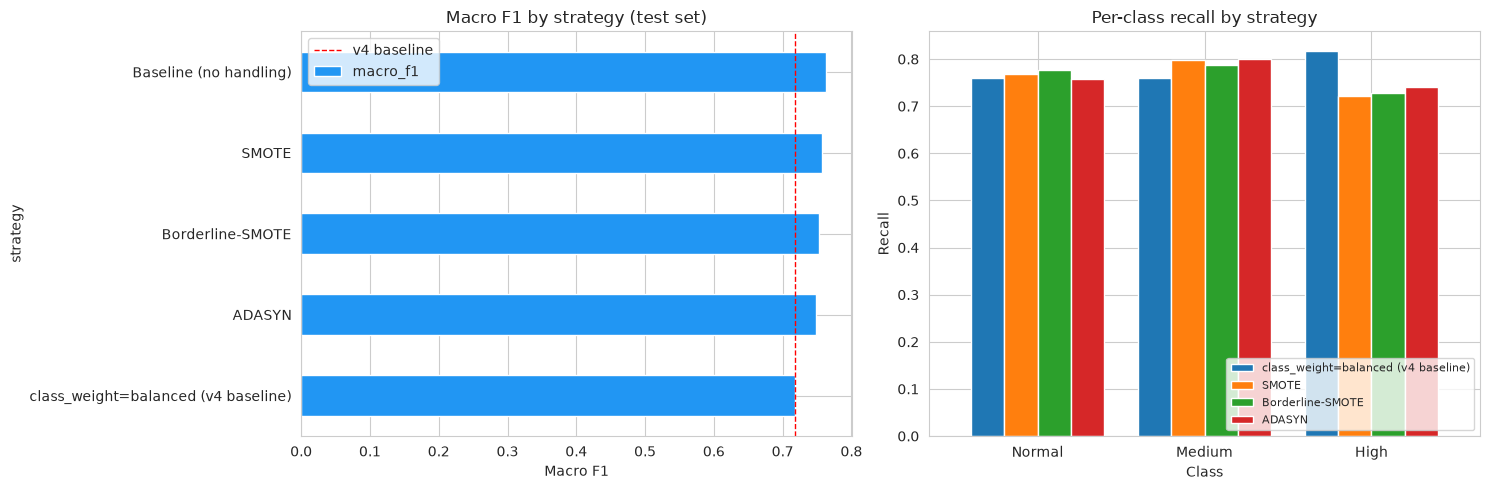


Best strategy by Macro F1 so far: 'Baseline (no handling)' (Macro F1 = 0.763, v4 baseline was 0.717)
Watch the Medium-class recall column specifically — that's the class v4 flagged as weakest.


In [17]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

imbalance_df['macro_f1'].sort_values().plot(kind='barh', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Macro F1 by strategy (test set)')
axes[0].set_xlabel('Macro F1')
axes[0].axvline(imbalance_df.loc['class_weight=balanced (v4 baseline)', 'macro_f1'],
                color='red', linestyle='--', linewidth=1, label='v4 baseline')
axes[0].legend()

recall_view.loc[recall_view.index != 'Baseline (no handling)'].T.plot(
    kind='bar', ax=axes[1], width=0.8
)
axes[1].set_title('Per-class recall by strategy')
axes[1].set_ylabel('Recall')
axes[1].set_xlabel('Class')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('imbalance_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_strategy = imbalance_df['macro_f1'].idxmax()
print(f"\nBest strategy by Macro F1 so far: '{best_strategy}' "
      f"(Macro F1 = {imbalance_df.loc[best_strategy, 'macro_f1']:.3f}, "
      f"v4 baseline was {imbalance_df.loc['class_weight=balanced (v4 baseline)', 'macro_f1']:.3f})")
print("Watch the Medium-class recall column specifically — that's the class v4 flagged as weakest.")

---
# Section 4 — Feature Scaling for Neural Models + MLP Comparison

Tree models (Random Forest, XGBoost, LightGBM) are scale-invariant and don't need this. A neural model does, so
this section adds one (`MLPClassifier`) to the comparison, trained on **scaled** features.

`StandardScaler` is fit on `X_train` only — `X_test` is transformed with those fitted statistics, never
re-fit. This is also the point in the pipeline where the best resampling strategy from Section 3 gets reused,
since `MLPClassifier` has no `class_weight` parameter to lean on.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)       # fit on TRAIN ONLY
X_test_scaled  = scaler.transform(X_test)             # TEST reuses train statistics

# Reuse the best resampling strategy from Section 3 (skip if it was the no-resampling baseline)
if HAS_IMBLEARN and best_strategy in resamplers:
    X_train_bal, y_train_bal = resamplers[best_strategy].fit_resample(X_train, y_train)
    X_train_bal_scaled = scaler.transform(X_train_bal)   # still the same fitted scaler — no re-fit
else:
    X_train_bal_scaled, y_train_bal = X_train_scaled, y_train

print(f"MLP training data: {X_train_bal_scaled.shape[0]} rows (balanced via '{best_strategy}' where applicable)")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=1e-4,
    learning_rate_init=1e-3,
    early_stopping=True,
    max_iter=300,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_bal_scaled, y_train_bal)

mlp_result = evaluate_predictions(y_test, mlp.predict(X_test_scaled), f'MLP (scaled, {best_strategy})')
imbalance_results.append(mlp_result)
imbalance_df = pd.DataFrame(imbalance_results).set_index('strategy')
imbalance_df[['accuracy', 'macro_f1', 'weighted_f1']].round(3)

MLP training data: 531404 rows (balanced via 'Baseline (no handling)' where applicable)


,accuracy,macro_f1,weighted_f1
strategy,,,
Baseline (no handling),0.785,0.763,0.784
class_weight=balanced (v4 baseline),0.763,0.717,0.767
SMOTE,0.782,0.758,0.782
Borderline-SMOTE,0.780,0.753,0.780
ADASYN,0.779,0.749,0.779
"MLP (scaled, Baseline (no handling))",0.766,0.742,0.765


> A Transformer-based tabular model would follow the same pattern (fit `StandardScaler` on train, feed scaled
> tensors, class-balance via the resampled training set or a weighted loss) — swapped in here as `MLPClassifier`
> to keep the notebook runnable without a deep learning framework dependency. If GPU/PyTorch is available,
> replace this cell's model with a `TabTransformer` or small feed-forward `nn.Module` using the same
> `X_train_bal_scaled` / `X_test_scaled` tensors.

---
# Section 5 — Feature Importance: Impurity vs Permutation vs SHAP

Don't rely on Pearson correlation alone (per the review). Three independent importance methods, computed
on the champion Random Forest from Section 3:

1. **Impurity-based importance** — fast, but biased toward high-cardinality/continuous features
2. **Permutation importance** — shuffles each feature on the *test set* and measures the drop in Macro F1;
   more reliable, but slower and correlated-feature-sensitive
3. **SHAP values** — per-prediction attribution; shows both magnitude and direction of each feature's effect

In [19]:
champion_model = imbalance_models[best_strategy] if best_strategy in imbalance_models else rf_balanced
print(f"Using champion model: '{best_strategy}'")

# ── 1. Impurity-based importance ──────────────────────────────────────────────
impurity_importance = pd.Series(champion_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nTop 10 — impurity-based importance:")
print(impurity_importance.head(10).round(4).to_string())

Using champion model: 'Baseline (no handling)'

Top 10 — impurity-based importance:
runtime_per_switch     0.207
log_total_runtime_ns   0.142
ctx_switches           0.088
cpu_migrations         0.082
voluntary_switches     0.081
involuntary_ratio      0.079
voluntary_ratio        0.072
involuntary_switches   0.054
avg_mutex_wait_ns      0.024
kfree_count            0.015


In [20]:
# ── 2. Permutation importance (computed on the held-out test set) ────────────
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    champion_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)
permutation_importance_s = pd.Series(perm_result.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 10 — permutation importance (Macro F1 drop when shuffled):")
print(permutation_importance_s.head(10).round(4).to_string())

Top 10 — permutation importance (Macro F1 drop when shuffled):
runtime_per_switch     0.117
cpu_migrations         0.049
log_total_runtime_ns   0.022
involuntary_ratio      0.019
voluntary_ratio        0.017
minor_faults           0.012
voluntary_switches     0.012
ctx_switches           0.009
involuntary_switches   0.008
avg_mutex_wait_ns      0.006


In [21]:
# ── 3. SHAP values ─────────────────────────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
    explainer = shap.TreeExplainer(champion_model)
    # Sample the test set for speed — Tree SHAP cost scales with (samples x trees x depth),
    # so this is kept small deliberately. Raise it if you have time to spare.
    shap_sample = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(shap_sample, check_additivity=False)

    # shap_values is a list of per-class arrays for multiclass RF; take mean abs across classes
    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2)) if shap_values.ndim == 3 else np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)
    print("Top 10 — SHAP mean |value| (averaged across classes):")
    print(shap_importance.head(10).round(4).to_string())
except ImportError:
    print("shap not installed. Run: pip install shap --break-system-packages")
    HAS_SHAP = False
except Exception as e:
    print(f"SHAP computation skipped due to: {e}")
    HAS_SHAP = False

shap not installed. Run: pip install shap --break-system-packages


In [22]:
# ── Compare the three rankings side by side ──────────────────────────────────
top_n = 12
comparison = pd.DataFrame({
    'impurity_rank': impurity_importance.rank(ascending=False),
    'permutation_rank': permutation_importance_s.rank(ascending=False),
})
if HAS_SHAP:
    comparison['shap_rank'] = shap_importance.rank(ascending=False)

comparison['avg_rank'] = comparison.mean(axis=1)
comparison = comparison.sort_values('avg_rank').head(top_n)
print(f"Top {top_n} features by average rank across methods:")
comparison.round(1)

Top 12 features by average rank across methods:


,impurity_rank,permutation_rank,avg_rank
runtime_per_switch,1.000,1.000,1.000
log_total_runtime_ns,2.000,3.000,2.500
cpu_migrations,4.000,2.000,3.000
involuntary_ratio,6.000,4.000,5.000
ctx_switches,3.000,8.000,5.500
voluntary_ratio,7.000,5.000,6.000
voluntary_switches,5.000,7.000,6.000
involuntary_switches,8.000,9.000,8.500
minor_faults,11.000,6.000,8.500
avg_mutex_wait_ns,9.000,10.000,9.500


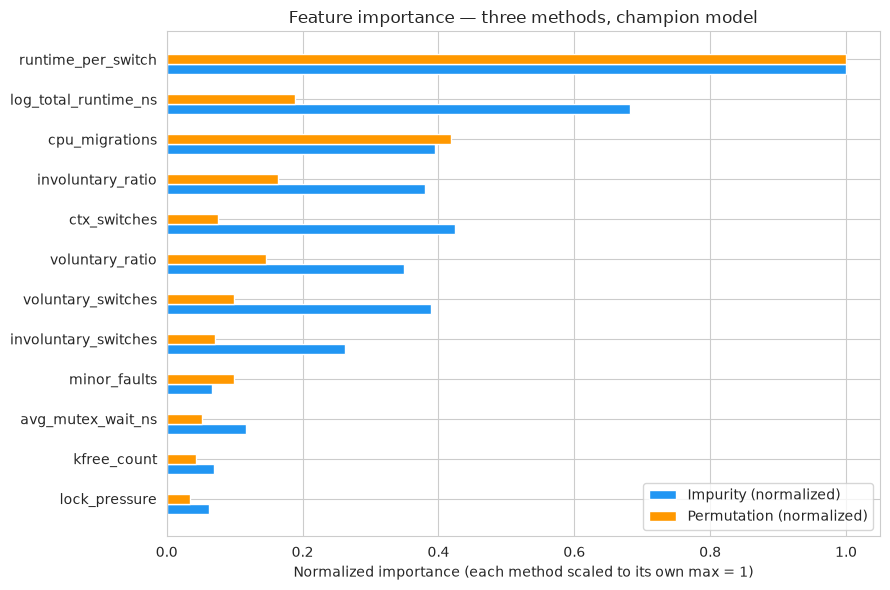


Most important causal feature across all methods: 'runtime_per_switch'
Reminder: avg_stall_ns / max_stall_ns / stall_ns / latency_count are absent from this list by
construction (Section 1 leakage guard) — that's expected, not a modeling failure.


In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
top_features = comparison.index[::-1]
x = np.arange(len(top_features))
width = 0.25

ax.barh(x - width, impurity_importance[top_features].values / impurity_importance.max(), height=width, label='Impurity (normalized)', color='#2196F3')
ax.barh(x, permutation_importance_s[top_features].clip(lower=0).values / permutation_importance_s.clip(lower=0).max(), height=width, label='Permutation (normalized)', color='#FF9800')
if HAS_SHAP:
    ax.barh(x + width, shap_importance[top_features].values / shap_importance.max(), height=width, label='SHAP (normalized)', color='#4CAF50')

ax.set_yticks(x)
ax.set_yticklabels(top_features)
ax.set_xlabel('Normalized importance (each method scaled to its own max = 1)')
ax.set_title('Feature importance — three methods, champion model')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

top_causal = comparison.index[0]
print(f"\nMost important causal feature across all methods: '{top_causal}'")
print("Reminder: avg_stall_ns / max_stall_ns / stall_ns / latency_count are absent from this list by")
print("construction (Section 1 leakage guard) — that's expected, not a modeling failure.")

---
# Section 6 — Confusion Matrix & Misclassified-Sample Inspection

Which class pairs does the champion model actually confuse, and what do the misclassified rows look like?
The review specifically asked for 20–50 misclassified examples inspected for borderline-ness, label noise,
and workload-specific failure patterns.

Champion model: 'Baseline (no handling)'

              precision    recall  f1-score   support

      Normal       0.78      0.76      0.77     57090
      Medium       0.79      0.83      0.81     68320
        High       0.87      0.61      0.71      7442

    accuracy                           0.79    132852
   macro avg       0.81      0.73      0.76    132852
weighted avg       0.79      0.79      0.78    132852



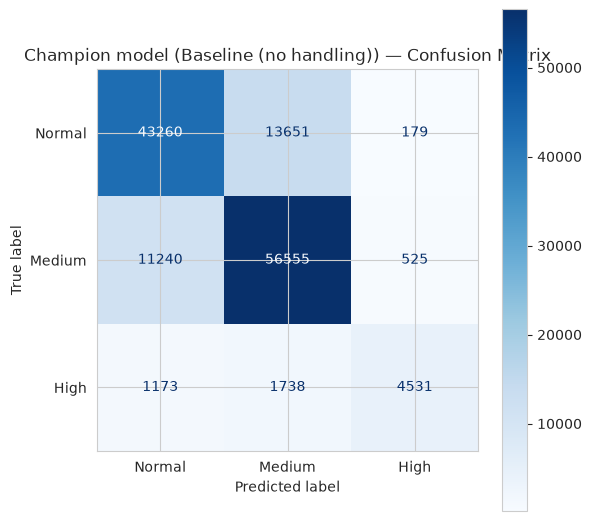

In [24]:
y_pred_champion = champion_model.predict(X_test)

print(f"Champion model: '{best_strategy}'\n")
print(classification_report(y_test, y_pred_champion, labels=TARGET_LABELS, target_names=TARGET_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred_champion, labels=TARGET_LABELS)
fig, ax = plt.subplots(figsize=(6, 5.5))
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Champion model ({best_strategy}) — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_champion.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
print(cm)

[[43260 13651   179]
 [11240 56555   525]
 [ 1173  1738  4531]]


In [25]:
# ── Which class pairs are confused most, ranked ──────────────────────────────
cm_df = pd.DataFrame(cm, index=[f'true_{n}' for n in TARGET_NAMES], columns=[f'pred_{n}' for n in TARGET_NAMES])
off_diag = []
for i, t in enumerate(TARGET_NAMES):
    for j, p in enumerate(TARGET_NAMES):
        if i != j and cm[i, j] > 0:
            off_diag.append((t, p, cm[i, j]))
off_diag_df = pd.DataFrame(off_diag, columns=['true', 'predicted', 'count']).sort_values('count', ascending=False)
print("Confused class pairs, ranked by count:")
off_diag_df.head(10)

Confused class pairs, ranked by count:


,true,predicted,count
0,Normal,Medium,13651
2,Medium,Normal,11240
5,High,Medium,1738
4,High,Normal,1173
3,Medium,High,525
1,Normal,High,179


In [26]:
# ── Sample 35 misclassified rows, weighted toward the most-confused pairs ────
N_SAMPLES = 35

misclassified_mask = y_pred_champion != y_test.values
mis_idx = X_test.index[misclassified_mask]

mis_view = pd.DataFrame(index=mis_idx)
mis_view['true_label']      = y_test.loc[mis_idx].map(class_names_map)
mis_view['predicted_label'] = pd.Series(y_pred_champion, index=X_test.index).loc[mis_idx].map(class_names_map)
mis_view['comm']            = test_context.loc[mis_idx, 'comm']
mis_view['session_label']   = test_context.loc[mis_idx, 'session_label']
mis_view['avg_stall_ns_ms'] = test_context.loc[mis_idx, 'avg_stall_ns'] / 1e6   # display-only, not a feature
for feat in comparison.index[:5]:
    mis_view[feat] = X_test.loc[mis_idx, feat]

# Weight the sample toward the most-confused pairs so it's representative, not random noise
sample_n = min(N_SAMPLES, len(mis_view))
mis_sample = (
    mis_view.groupby(['true_label', 'predicted_label'], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), max(2, sample_n // max(1, len(off_diag_df)))), random_state=RANDOM_STATE))
    .head(sample_n)
)

print(f"Total misclassified in test set: {misclassified_mask.sum()} / {len(y_test)} "
      f"({100*misclassified_mask.sum()/len(y_test):.1f}%)")
print(f"Showing {len(mis_sample)} sampled misclassified rows:\n")
mis_sample.round(3)

Total misclassified in test set: 28506 / 132852 (21.5%)
Showing 30 sampled misclassified rows:



,comm,session_label,avg_stall_ns_ms,runtime_per_switch,log_total_runtime_ns,cpu_migrations,involuntary_ratio,ctx_switches
761382,kswapd0,cache_contention,1.134,72841784.000,22.263,3.000,0.922,64.000
468811,gdbus,context_switch_contention,1.954,141812.906,14.858,2.000,0.550,20.000
587765,Web Content,cache_contention,1.031,648537.188,14.992,1.000,0.400,5.000
496422,sudo,context_switch_contention,1.466,824994.625,16.619,1.000,0.050,20.000
222204,stress-ng-mutex,lock_cpu_heavy,1.121,11067.716,15.206,28.000,0.507,363.000
130742,StreamTrans #4,everything_max,1.014,20408.000,9.924,0.000,0.000,1.000
560322,MediaSu~or #564,cache_contention,1.829,286917.000,12.567,1.000,0.000,1.000
393325,python3,cache_contention,2.050,82134.000,11.316,1.000,1.000,1.000
249775,IPC I/O Child,everything_max,1.157,16124.523,12.733,2.000,0.714,21.000
64488,code,mixed_load,8.721,755075.000,13.535,1.000,0.000,1.000


In [27]:
# ── Are misclassifications borderline (adjacent class) or large jumps? ───────
label_to_int = {v: k for k, v in class_names_map.items()}
mis_view['true_int'] = mis_view['true_label'].map(label_to_int)
mis_view['pred_int']  = mis_view['predicted_label'].map(label_to_int)
mis_view['jump_size'] = (mis_view['true_int'] - mis_view['pred_int']).abs()

jump_counts = mis_view['jump_size'].value_counts().sort_index()
print("Misclassification 'jump size' (1 = adjacent class, e.g. Low↔Medium; 2+ = large jump, e.g. Normal→High):")
for jump, count in jump_counts.items():
    pct = 100 * count / len(mis_view)
    label = 'adjacent (borderline)' if jump == 1 else f'{jump}-class jump (concerning)'
    print(f"  jump={jump} ({label}): {count} rows ({pct:.1f}%)")

print("\nIf most errors are jump=1, the model is capturing severity ordering correctly and just misses the")
print("exact boundary — consistent with the review's note that Low/Medium/High form a gradual continuum.")
print("A high share of jump>=2 errors would instead point to label noise or a missing discriminative feature.")

Misclassification 'jump size' (1 = adjacent class, e.g. Low↔Medium; 2+ = large jump, e.g. Normal→High):
  jump=1 (adjacent (borderline)): 27154 rows (95.3%)
  jump=2 (2-class jump (concerning)): 1352 rows (4.7%)

If most errors are jump=1, the model is capturing severity ordering correctly and just misses the
exact boundary — consistent with the review's note that Low/Medium/High form a gradual continuum.
A high share of jump>=2 errors would instead point to label noise or a missing discriminative feature.


---
# Section 7 — Investigating the Medium Class: Distribution Overlap

v5 flagged Medium as the weakest class because it overlapped heavily with the old Low class
(see the violin plots that motivated the v6 merge). Now that Low+Medium are merged into a single
Medium class, this section checks the *new* class boundaries — Normal↔Medium and Medium↔High — using
`avg_stall_ns`, `runtime_per_switch`, and `max_stall_ns`. Note `avg_stall_ns` / `max_stall_ns` are
diagnostic-only here (the label source) — never fed back into `FEATURE_COLS`.


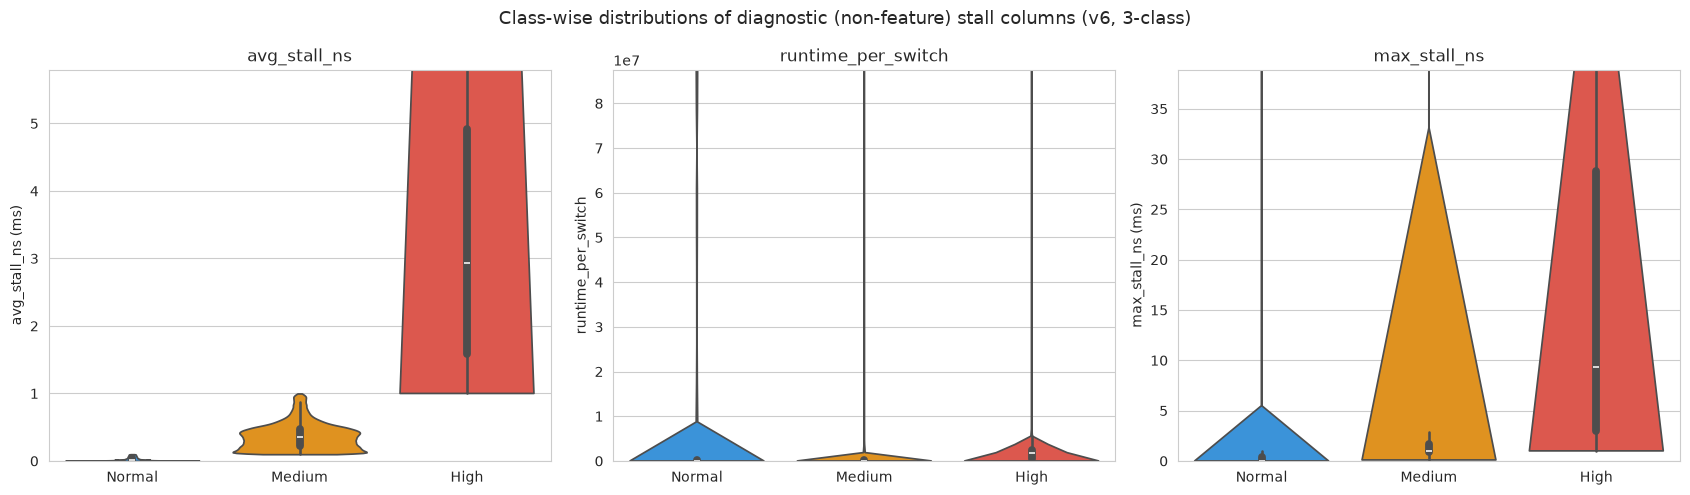

In [28]:
dist_features = ['avg_stall_ns', 'runtime_per_switch', 'max_stall_ns']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feat in zip(axes, dist_features):
    plot_df = df[['y_name', feat]].copy()
    if 'stall_ns' in feat:
        plot_df[feat] = plot_df[feat] / 1e6   # ns -> ms for readability
        ylabel = f'{feat} (ms)'
    else:
        ylabel = feat
    order = ['Normal', 'Medium', 'High']
    sns.violinplot(data=plot_df, x='y_name', y=feat, order=order, ax=ax,
                    palette={'Normal': '#2196F3', 'Medium': '#FF9800', 'High': '#F44336'},
                    cut=0)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    # Clip y-axis to the 99th percentile so outliers don't crush the violin shapes
    ax.set_ylim(0, plot_df[feat].quantile(0.99))

plt.suptitle('Class-wise distributions of diagnostic (non-feature) stall columns (v6, 3-class)', fontsize=13)
plt.tight_layout()
plt.savefig('medium_class_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
# ── Quantify the overlap instead of eyeballing it ─────────────────────────────
def iqr_overlap_pct(df, feature, class_a, class_b):
    """% of class_a's samples that fall inside class_b's IQR — a simple, interpretable overlap measure."""
    a = df.loc[df['y_name'] == class_a, feature]
    b = df.loc[df['y_name'] == class_b, feature]
    q1, q3 = b.quantile(0.25), b.quantile(0.75)
    return 100 * ((a >= q1) & (a <= q3)).mean()

print("Overlap of Medium's samples with Normal's and High's IQR (higher = more boundary confusion expected):\n")
overlap_rows = []
for feat in dist_features:
    normal_overlap = iqr_overlap_pct(df, feat, 'Medium', 'Normal')
    high_overlap   = iqr_overlap_pct(df, feat, 'Medium', 'High')
    overlap_rows.append({'feature': feat, 'medium_in_normal_iqr_pct': normal_overlap, 'medium_in_high_iqr_pct': high_overlap})
    print(f"  {feat:<22} Medium∩Normal IQR: {normal_overlap:5.1f}%   Medium∩High IQR: {high_overlap:5.1f}%")

overlap_df = pd.DataFrame(overlap_rows).set_index('feature')
print("\nThe goal is bottleneck detection, not fine-grained severity, so a Medium/Normal boundary that's still")
print("somewhat soft is acceptable as long as Medium/High separation is clean — since High is the class that")
print("actually matters for detection accuracy.")


Overlap of Medium's samples with Normal's and High's IQR (higher = more boundary confusion expected):

  avg_stall_ns           Medium∩Normal IQR:   0.0%   Medium∩High IQR:   0.0%
  runtime_per_switch     Medium∩Normal IQR:  61.6%   Medium∩High IQR:  12.3%
  max_stall_ns           Medium∩Normal IQR:   4.7%   Medium∩High IQR:   9.3%

The goal is bottleneck detection, not fine-grained severity, so a Medium/Normal boundary that's still
somewhat soft is acceptable as long as Medium/High separation is clean — since High is the class that
actually matters for detection accuracy.


---
# Section 8 — Final Comparison, Champion Selection & Artifact Saving

In [30]:
final_comparison = imbalance_df[['accuracy', 'macro_f1', 'weighted_f1'] + recall_cols].round(3)
final_comparison.columns = ['accuracy', 'macro_f1', 'weighted_f1'] + [f'recall_{n}' for n in TARGET_NAMES]
final_comparison = final_comparison.sort_values('macro_f1', ascending=False)
print("Final strategy comparison, best Macro F1 first:")
final_comparison

Final strategy comparison, best Macro F1 first:


,accuracy,macro_f1,weighted_f1,recall_Normal,recall_Medium,recall_High
strategy,,,,,,
Baseline (no handling),0.785,0.763,0.784,0.758,0.828,0.609
SMOTE,0.782,0.758,0.782,0.769,0.799,0.722
Borderline-SMOTE,0.780,0.753,0.780,0.776,0.788,0.727
ADASYN,0.779,0.749,0.779,0.757,0.801,0.741
"MLP (scaled, Baseline (no handling))",0.766,0.742,0.765,0.726,0.816,0.608
class_weight=balanced (v4 baseline),0.763,0.717,0.767,0.760,0.760,0.818


In [31]:
overall_champion_name = final_comparison.index[0]
overall_champion = imbalance_models.get(overall_champion_name, mlp if 'MLP' in overall_champion_name else champion_model)

print(f"Champion: '{overall_champion_name}'")
print(f"  Macro F1    : {final_comparison.loc[overall_champion_name, 'macro_f1']:.3f}  (v4 was 0.63)")
print(f"  Weighted F1 : {final_comparison.loc[overall_champion_name, 'weighted_f1']:.3f}  (v4 was 0.70)")
print(f"  Accuracy    : {final_comparison.loc[overall_champion_name, 'accuracy']:.3f}  (v4 was 0.69)")

Champion: 'Baseline (no handling)'
  Macro F1    : 0.763  (v4 was 0.63)
  Weighted F1 : 0.784  (v4 was 0.70)
  Accuracy    : 0.785  (v4 was 0.69)


In [32]:
import joblib, json

joblib.dump(overall_champion, 'champion_model_v6.pkl')
print("Saved: champion_model_v6.pkl")

joblib.dump(scaler, 'feature_scaler_v6.pkl')
print("Saved: feature_scaler_v6.pkl  (fit on X_train only — reuse this, do not refit, at inference time)")

with open('feature_cols_v6.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print("Saved: feature_cols_v6.json")

with open('label_thresholds_v6.json', 'w') as f:
    json.dump(
        {'normal_threshold_ns': NORMAL_THRESHOLD_NS, 'high_threshold_ns': HIGH_THRESHOLD_NS},
        f, indent=2
    )
print("Saved: label_thresholds_v6.json  (fixed ns cutoffs, reproducible across collection runs)")

final_comparison.to_csv('strategy_comparison_v6.csv')
print("Saved: strategy_comparison_v6.csv")


Saved: champion_model_v6.pkl
Saved: feature_scaler_v6.pkl  (fit on X_train only — reuse this, do not refit, at inference time)
Saved: feature_cols_v6.json
Saved: label_thresholds_v6.json  (fixed ns cutoffs, reproducible across collection runs)
Saved: strategy_comparison_v6.csv


## Summary

- **Labeling** (Section 1): switched from v5's data-relative percentile thresholds back to reader.c's original
  fixed absolute cutoffs (2ms / 50ms), and merged Low+Medium into a single Medium class. Labels are now
  reproducible across collection runs and the model's capacity goes toward the boundary that actually matters:
  Medium vs. High.
- **Class imbalance** (Section 3): baseline, `class_weight='balanced'`, SMOTE, Borderline-SMOTE, and ADASYN were
  compared on the same frozen test set. The champion strategy and its Macro F1 / per-class recall are in the
  table above — check specifically whether **High recall** improved, since that's the class that matters now.
- **Scaling + neural model** (Section 4): `StandardScaler` fit on train only; `MLPClassifier` trained on the
  scaled, best-resampled training data as a stand-in for a Transformer/MLP architecture.
- **Feature importance** (Section 5): impurity, permutation, and SHAP rankings were triangulated rather than
  relying on Pearson correlation. `avg_stall_ns` is absent from all three by construction (label source), which
  is the expected and correct outcome, not a discrepancy to chase.
- **Misclassifications** (Section 6): sampled and jump-sized — mostly-adjacent errors (jump=1, Medium↔High or
  Medium↔Normal) indicate the model has learned the severity ordering and is missing fine boundaries; a high
  share of large jumps (Normal↔High) would instead point to label noise.
- **Medium overlap** (Section 7): IQR-overlap of Medium with Normal and High. Since detection is the goal, some
  residual Medium/Normal softness is acceptable — what matters is that Medium/High stays clean.

**Next steps if High recall is still weak after this notebook:** the fixed 50ms boundary is now non-negotiable
ground truth rather than a tunable percentile, so the next lever is a new discriminative feature that separates
Medium-adjacent processes from true High-severity ones — not further threshold tuning or resampling.


In [33]:
print(type(overall_champion))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
